In [1]:
import os
import time
from datetime import datetime

import numpy as np
import torch
import torch.nn.functional as F
import triton
import triton.language as tl

# ===============================================================
# CUDA 初始化
# ===============================================================
torch.cuda.init()
DEVICE_ID = 0
torch.cuda.set_device(DEVICE_ID)
device = torch.device(f"cuda:{DEVICE_ID}")
print(f"[INIT] 当前运行设备: {device}")

# ===============================================================
# 声学参数 / 分辨率
# ===============================================================
sigma = 0.1e-3     # m，既作为核参数也作为网格步长（分辨率）
vs = 1500.0        # m/s
delta_time = 25e-9 # s, 采样间隔

# ===============================================================
# 仿真时间范围：起始下标 / 结束下标（不包含结束下标）
# ===============================================================
t_start_idx = 1400  # 包含.   如不需要，改为 0
t_end_idx   = 1900  # 不包含   如不需要，改为 采样点数
# ===============================================================

n_time_sub = t_end_idx - t_start_idx

# 探头位置 & 参考信号（仅用于尺寸和 target）
# ===============================================================
loc_all = np.loadtxt("data/sensor_location_129_quarter.txt")  # (4096,3)
sensor_data = np.loadtxt("data/simulated_signal_129_quarter.txt")       # (4096, n_time)
sensor_data_new_pos = np.loadtxt('data/simulated_signal_rotated_120.txt')
sensor_loc_new_pos = np.loadtxt('data/sensor_location_rotated_120deg.txt')

# （可选）下采样探头以降低计算量
sel_step = 2  # 每隔 sel_step 取一个探头，1 表示全取
sel_idx = np.arange(0, loc_all.shape[0], sel_step)
loc_part = loc_all[sel_idx]  # (N_sensors, 3)
sensor_loc_new_pos_part = sensor_loc_new_pos[sel_idx]  # (N_sensors, 3)

sensor_data_part = sensor_data[sel_idx][:, t_start_idx:t_end_idx]  # 只取时间段
sensor_data_new_pos_part = sensor_data_new_pos[sel_idx][:, t_start_idx:t_end_idx]  # 只取时间段

signals = np.vstack((sensor_data_part, sensor_data_new_pos_part))

loc = np.vstack((loc_part, sensor_loc_new_pos_part))
n_sensors = loc.shape[0]
print(f"[INFO] 使用探头数={n_sensors} (每 {sel_step} 个取一个)")

sens_x = torch.tensor(loc[:, 0], dtype=torch.float32, device=device).contiguous()
sens_y = torch.tensor(loc[:, 1], dtype=torch.float32, device=device).contiguous()
sens_z = torch.tensor(loc[:, 2], dtype=torch.float32, device=device).contiguous()

# ===============================================================
# 源点：基于分辨率 sigma 的 256^3 网格初始化
# ===============================================================
GRID_SIZE = 256
voxel_size = sigma  # 网格步长 = 分辨率
center = (GRID_SIZE - 1) / 2.0
coords = (np.arange(GRID_SIZE) - center) * voxel_size  # 从 -center*voxel_size 到 +center*voxel_size
xg, yg, zg = np.meshgrid(coords, coords, coords, indexing="ij")
src_x_np = xg.astype(np.float32).ravel()
src_y_np = yg.astype(np.float32).ravel()
src_z_np = zg.astype(np.float32).ravel()
n_sources = src_x_np.size
print(f"[INFO] grid sources = {n_sources} ({GRID_SIZE}^3), step={voxel_size} m")

src_x = torch.tensor(src_x_np, device=device).contiguous()
src_y = torch.tensor(src_y_np, device=device).contiguous()
src_z = torch.tensor(src_z_np, device=device).contiguous()

# 源强度 Pc 作为可训练参数
Pc_param = torch.nn.Parameter(torch.randn(n_sources, device=device))

# ===============================================================
# Triton 前向核：Gaussian
# out[s, t] = sum_k Pc[k] * 0.5 * ((r_k - vs*t)/r_k) * exp(-(r_k - vs*t)^2 / (2*sigma^2))
# ===============================================================
@triton.jit
def forward_kernel(
    Pc_ptr, src_x_ptr, src_y_ptr, src_z_ptr,
    sens_x_ptr, sens_y_ptr, sens_z_ptr,
    out_ptr,
    n_sources, n_time_sub,
    t_start_idx,
    delta_t, vs, sigma,
    stride_out_s, stride_out_t,
    BLOCK_K: tl.constexpr, BLOCK_T: tl.constexpr
):
    pid_t = tl.program_id(0)  # 时间块
    pid_s = tl.program_id(1)  # 探头
    t_offsets = tl.arange(0, BLOCK_T)
    t_idx_rel = pid_t * BLOCK_T + t_offsets
    t_mask = t_idx_rel < n_time_sub
    t_vals = (t_start_idx + t_idx_rel) * delta_t  # [T]

    sx = tl.load(sens_x_ptr + pid_s)
    sy = tl.load(sens_y_ptr + pid_s)
    sz = tl.load(sens_z_ptr + pid_s)

    acc = tl.zeros((BLOCK_T,), dtype=tl.float32)

    for k in range(0, n_sources, BLOCK_K):
        idx_k = k + tl.arange(0, BLOCK_K)
        mask_k = idx_k < n_sources

        px = tl.load(src_x_ptr + idx_k, mask=mask_k, other=0.0)
        py = tl.load(src_y_ptr + idx_k, mask=mask_k, other=0.0)
        pz = tl.load(src_z_ptr + idx_k, mask=mask_k, other=0.0)
        pc = tl.load(Pc_ptr    + idx_k, mask=mask_k, other=0.0)

        dx = sx - px
        dy = sy - py
        dz = sz - pz
        r = tl.sqrt(dx * dx + dy * dy + dz * dz + 1e-12)  # [K]

        r_mat  = r[:, None]      # [K,1]
        pc_mat = pc[:, None]     # [K,1]
        t_mat  = t_vals[None, :] # [1,T]

        rt = r_mat - vs * t_mat
        contrib = pc_mat * 0.5 * (rt / r_mat) * tl.exp(-(rt * rt) / (2.0 * sigma * sigma))
        contrib = tl.where(mask_k[:, None], contrib, 0.0)
        acc += tl.sum(contrib, axis=0)

    out_ptrs = out_ptr + pid_s * stride_out_s + t_idx_rel * stride_out_t
    tl.store(out_ptrs, acc, mask=t_mask)

# ===============================================================
# Triton 反向核：对 Pc 求梯度
# ===============================================================
@triton.jit
def backward_kernel(
    src_x_ptr, src_y_ptr, src_z_ptr,
    sens_x_ptr, sens_y_ptr, sens_z_ptr,
    grad_out_ptr, grad_pc_ptr,
    n_sources, n_sensors, n_time_sub,
    t_start_idx,
    delta_t, vs, sigma,
    stride_go_s, stride_go_t,
    BLOCK_K: tl.constexpr, BLOCK_T: tl.constexpr
):
    pid_t = tl.program_id(0)
    pid_s = tl.program_id(1)
    t_offsets = tl.arange(0, BLOCK_T)
    t_idx_rel = pid_t * BLOCK_T + t_offsets
    t_mask = t_idx_rel < n_time_sub
    t_vals = (t_start_idx + t_idx_rel) * delta_t

    sx = tl.load(sens_x_ptr + pid_s)
    sy = tl.load(sens_y_ptr + pid_s)
    sz = tl.load(sens_z_ptr + pid_s)

    go_ptrs = grad_out_ptr + pid_s * stride_go_s + t_idx_rel * stride_go_t
    go = tl.load(go_ptrs, mask=t_mask, other=0.0)  # [T]

    for k in range(0, n_sources, BLOCK_K):
        idx_k = k + tl.arange(0, BLOCK_K)
        mask_k = idx_k < n_sources

        px = tl.load(src_x_ptr + idx_k, mask=mask_k, other=0.0)
        py = tl.load(src_y_ptr + idx_k, mask=mask_k, other=0.0)
        pz = tl.load(src_z_ptr + idx_k, mask=mask_k, other=0.0)

        dx = sx - px
        dy = sy - py
        dz = sz - pz
        r = tl.sqrt(dx * dx + dy * dy + dz * dz + 1e-12)  # [K]

        r_mat = r[:, None]
        t_mat = t_vals[None, :]

        rt = r_mat - vs * t_mat
        dfdpc = 0.5 * (rt / r_mat) * tl.exp(-(rt * rt) / (2.0 * sigma * sigma))
        dfdpc = tl.where(mask_k[:, None], dfdpc, 0.0)

        grad_k = tl.sum(dfdpc * go[None, :], axis=1)  # [K]
        tl.atomic_add(grad_pc_ptr + idx_k, grad_k, mask=mask_k)

# ===============================================================
# 自定义 Autograd Function
# ===============================================================
class GaussianSimFunction(torch.autograd.Function):
    @staticmethod
    def forward(ctx,
                Pc, src_x, src_y, src_z,
                sens_x, sens_y, sens_z,
                t_start_idx, n_time_sub,
                delta_t, vs, sigma):
        out = torch.empty((sens_x.numel(), n_time_sub), device=Pc.device, dtype=torch.float32)

        BLOCK_T = 128
        BLOCK_K = 128
        grid = (triton.cdiv(n_time_sub, BLOCK_T), sens_x.numel())

        forward_kernel[grid](
            Pc, src_x, src_y, src_z,
            sens_x, sens_y, sens_z,
            out,
            Pc.numel(), n_time_sub,
            t_start_idx,
            delta_t, vs, sigma,
            out.stride(0), out.stride(1),
            BLOCK_K=BLOCK_K, BLOCK_T=BLOCK_T,
            num_warps=4, num_stages=2
        )
        ctx.save_for_backward(src_x, src_y, src_z, sens_x, sens_y, sens_z)
        ctx.n_sources = Pc.numel()
        ctx.n_sensors = sens_x.numel()
        ctx.n_time_sub = n_time_sub
        ctx.t_start_idx = t_start_idx
        ctx.delta_t = delta_t
        ctx.vs = vs
        ctx.sigma = sigma
        return out

    @staticmethod
    def backward(ctx, grad_out):
        src_x, src_y, src_z, sens_x, sens_y, sens_z = ctx.saved_tensors
        grad_pc = torch.zeros(ctx.n_sources, device=grad_out.device, dtype=torch.float32)

        BLOCK_T = 128
        BLOCK_K = 128
        grid = (triton.cdiv(ctx.n_time_sub, BLOCK_T), ctx.n_sensors)

        backward_kernel[grid](
            src_x, src_y, src_z,
            sens_x, sens_y, sens_z,
            grad_out.contiguous(), grad_pc,
            ctx.n_sources, ctx.n_sensors, ctx.n_time_sub,
            ctx.t_start_idx,
            ctx.delta_t, ctx.vs, ctx.sigma,
            grad_out.stride(0), grad_out.stride(1),
            BLOCK_K=BLOCK_K, BLOCK_T=BLOCK_T,
            num_warps=4, num_stages=2
        )
        return grad_pc, None, None, None, None, None, None, None, None, None, None, None

def gaussian_sim(Pc, src_x, src_y, src_z, sens_x, sens_y, sens_z,
                 t_start_idx, n_time_sub, delta_t, vs, sigma):
    return GaussianSimFunction.apply(Pc, src_x, src_y, src_z,
                                     sens_x, sens_y, sens_z,
                                     t_start_idx, n_time_sub,
                                     delta_t, vs, sigma)

# ===============================================================
# TGV 正则
# ===============================================================
def forward_diff(tensor, dim):
    diff = torch.roll(tensor, shifts=-1, dims=dim) - tensor
    idx = [slice(None)] * tensor.ndim
    idx[dim] = slice(-1, None)
    diff[tuple(idx)] = 0.0
    return diff

def tgv2_regularization(A_flat, grid_shape, alpha0=2.0, alpha1=1.0, eps=1e-8):
    A = A_flat.view(*grid_shape)
    gx = forward_diff(A, 0)
    gy = forward_diff(A, 1)
    gz = forward_diff(A, 2)
    grad_mag = torch.sqrt(gx * gx + gy * gy + gz * gz + eps)
    first_term = grad_mag.mean()

    gxx = forward_diff(gx, 0)
    gyy = forward_diff(gy, 1)
    gzz = forward_diff(gz, 2)
    gxy = 0.5 * (forward_diff(gx, 1) + forward_diff(gy, 0))
    gxz = 0.5 * (forward_diff(gx, 2) + forward_diff(gz, 0))
    gyz = 0.5 * (forward_diff(gy, 2) + forward_diff(gz, 1))
    second_sq = gxx * gxx + gyy * gyy + gzz * gzz \
                + 2.0 * (gxy * gxy + gxz * gxz + gyz * gyz)
    second_term = torch.sqrt(second_sq + eps).mean()
    return alpha1 * first_term + alpha0 * second_term

GRID_SHAPE = (GRID_SIZE, GRID_SIZE, GRID_SIZE)
lambda_tv = 2.0
tgv_alpha0 = 2.0
tgv_alpha1 = 1.0

# ===============================================================
# 训练循环
# ===============================================================
if __name__ == "__main__":
    print("\n[Train] 开始训练循环 (直角坐标 Gaussian)...")
    target = torch.tensor(signals, dtype=torch.float32, device=device).contiguous()

    optimizer = torch.optim.Adam([Pc_param], lr=0.5)
    max_epochs = 200
    root_ckpt_dir = "checkpoints_03"
    os.makedirs(root_ckpt_dir, exist_ok=True)

    for epoch in range(max_epochs):
        t_start = time.time()

        optimizer.zero_grad()
        Pc = F.softplus(Pc_param)  # 保持非负

        y_pred = gaussian_sim(Pc, src_x, src_y, src_z, sens_x, sens_y, sens_z,
                              t_start_idx, n_time_sub, delta_time, vs, sigma)

        data_loss = torch.mean((y_pred - target) ** 2)
        tv_loss = tgv2_regularization(Pc, GRID_SHAPE, alpha0=tgv_alpha0, alpha1=tgv_alpha1)
        loss = data_loss + lambda_tv * tv_loss

        loss.backward()
        optimizer.step()

        epoch_time = time.time() - t_start
        grad_mean = Pc_param.grad.mean().item() if Pc_param.grad is not None else 0.0
        print(f"[Epoch {epoch+1}/{max_epochs}] "
              f"loss={loss.item():.6e}, data={data_loss.item():.6e}, tv={tv_loss.item():.6e}, "
              f"grad_mean={grad_mean:.4e}, time={epoch_time:.2f}s, "
              f"Pc_min={Pc.min().item():.3e}, Pc_mean={Pc.mean().item():.3e}")

        # 保存 checkpoint
        if (epoch + 1) % 20 == 0:
            ts = datetime.now().strftime("%Y%m%d_%H%M%S")
            ckpt_dir = os.path.join(root_ckpt_dir, f"epoch{epoch + 1:03d}_{ts}")
            os.makedirs(ckpt_dir, exist_ok=True)
            torch.save({
                "epoch": epoch + 1,
                "Pc_state": Pc.detach().cpu(),
                "optimizer_state": optimizer.state_dict(),
                "loss": loss.item(),
                "epoch_time": epoch_time,
            }, os.path.join(ckpt_dir, "model.pt"))
            print(f"  [Checkpoint] 模型已保存到: {ckpt_dir}")

    print("[Train] 完成。")

[INIT] 当前运行设备: cuda:0
[INFO] 使用探头数=130 (每 2 个取一个)
[INFO] grid sources = 16777216 (256^3), step=0.0001 m

[Train] 开始训练循环 (直角坐标 Gaussian)...
[Epoch 1/200] loss=1.713633e+01, data=2.678999e+00, tv=7.228664e+00, grad_mean=3.8016e-07, time=40.26s, Pc_min=3.631e-03, Pc_mean=8.060e-01
[Epoch 2/200] loss=1.096221e+01, data=1.344109e+00, tv=4.809050e+00, grad_mean=2.5293e-07, time=0.01s, Pc_min=4.895e-03, Pc_mean=7.728e-01
[Epoch 3/200] loss=7.724446e+00, data=8.644080e-01, tv=3.430019e+00, grad_mean=1.9873e-07, time=0.01s, Pc_min=6.649e-03, Pc_mean=7.539e-01
[Epoch 4/200] loss=6.286087e+00, data=7.021354e-01, tv=2.791975e+00, grad_mean=1.8487e-07, time=0.01s, Pc_min=7.417e-03, Pc_mean=7.357e-01
[Epoch 5/200] loss=5.519294e+00, data=6.339016e-01, tv=2.442696e+00, grad_mean=1.8055e-07, time=0.01s, Pc_min=6.964e-03, Pc_mean=7.120e-01
[Epoch 6/200] loss=4.899393e+00, data=5.602160e-01, tv=2.169589e+00, grad_mean=1.7156e-07, time=0.01s, Pc_min=6.103e-03, Pc_mean=6.824e-01
[Epoch 7/200] loss=4.30234

[Load] 从 checkpoints_03/epoch200_20260130_220344/model.pt 读取模型参数...
[Info] 自动检测立方体尺寸: 256³


/tmp/ipykernel_1150916/1728211028.py:42: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(ckpt_path, map_location="cpu")


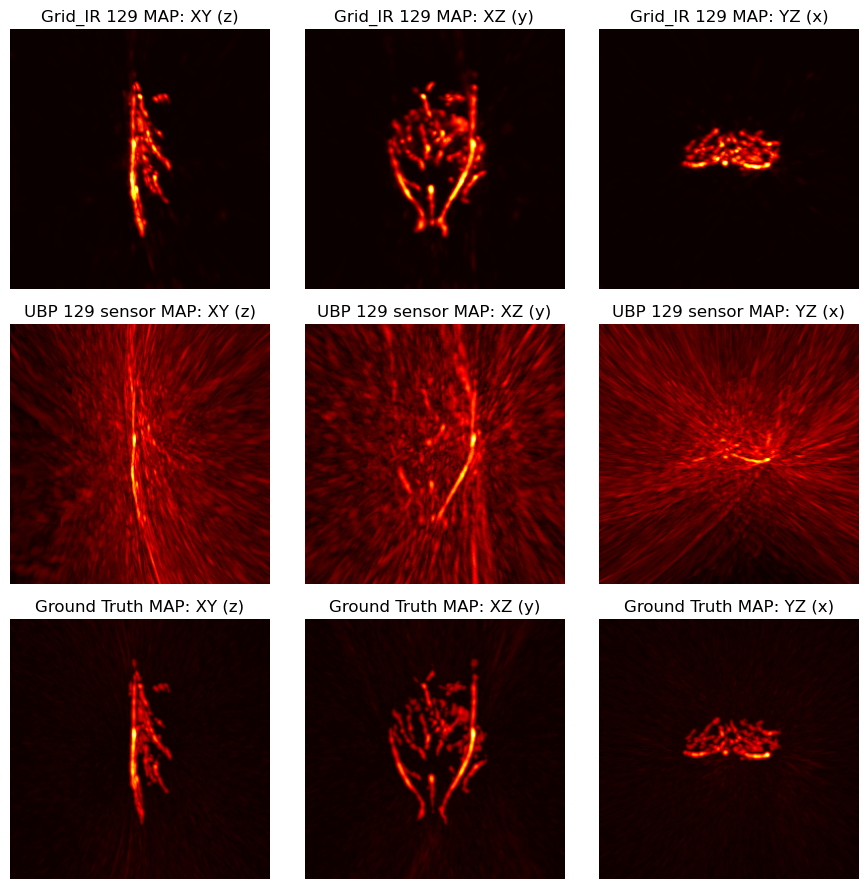

In [2]:
import os
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from scipy.io import loadmat

plt.rcParams['figure.figsize'] = (9, 3)

def normalize(volume):
    v_min, v_max = volume.min(), volume.max()
    return (volume - v_min) / (v_max - v_min + 1e-8)

def load_mat_volume(mat_path, key):
    data = loadmat(mat_path)[key]
    return np.asarray(data, dtype=np.float32)

def preprocess_gt(gt):
    # MATLAB 中 permute(gt,[3 2 1]) + flip(gt,3)
    gt = np.transpose(gt, (2, 1, 0))
    gt = np.flip(gt, axis=2)
    return gt

def get_mips(volume):
    mip_xy = np.max(volume, axis=2)  # 沿 z 投影
    mip_xz = np.max(volume, axis=1)  # 沿 y 投影
    mip_yz = np.max(volume, axis=0)  # 沿 x 投影
    return mip_xy, mip_xz, mip_yz

# ---------------------------- 1) checkpoint 重建体 ---------------------------- #
ckpt_dir = "checkpoints_03"
last_ckpt = None
if os.path.exists(ckpt_dir):
    subdirs = [os.path.join(ckpt_dir, d) for d in os.listdir(ckpt_dir)
               if os.path.isdir(os.path.join(ckpt_dir, d))]
    if subdirs:
        last_ckpt = sorted(subdirs)[-1]
ckpt_path = os.path.join(last_ckpt, "model.pt") if last_ckpt else None
if ckpt_path is None or not os.path.exists(ckpt_path):
    raise FileNotFoundError("未找到 checkpoint，请确保路径正确！")
print(f"[Load] 从 {ckpt_path} 读取模型参数...")
ckpt = torch.load(ckpt_path, map_location="cpu")

# 新的键名为 Pc_state，训练时已 softplus 后保存
Pc_tensor = ckpt["Pc_state"] #A_state
K = Pc_tensor.numel()
N = int(round(K ** (1 / 3)))
print(f"[Info] 自动检测立方体尺寸: {N}³")
Pc_3d = Pc_tensor.reshape(N, N, N).detach().cpu().numpy()
Pc_norm = normalize(Pc_3d)

# 若需 Sato 滤波，取消下方注释
# sato_vol = sato(Pc_norm, sigmas=np.linspace(0.8, 3, 5), black_ridges=False)
# Pc_norm = normalize(sato_vol)

# ---------------------------- 2) simu_xx_true 数据 ---------------------------- #
unprocessed = load_mat_volume('ubp_65.mat', 'signal_recon')  # 如需 512 版本改文件名
unprocessed = np.maximum(unprocessed, 0)
unprocessed_norm = normalize(unprocessed)

# ---------------------------- 3) Ground Truth ---------------------------- #
gt = load_mat_volume('GT_liver.mat', 'gt')
gt = preprocess_gt(gt)
gt = np.maximum(gt, 0)
gt_norm = normalize(gt)

# ---------------------------- 统一绘制 3×3 大图 ---------------------------- #
mips_data = [
    ("Grid_IR 129", Pc_norm),
    ("UBP 129 sensor", unprocessed_norm),
    ("Ground Truth", gt_norm)
]
fig, axes = plt.subplots(3, 3, figsize=(9, 9))  # 3×3 网格
for i, (title_prefix, vol) in enumerate(mips_data):
    mip_xy, mip_xz, mip_yz = get_mips(vol)
    axes[i, 0].imshow(mip_xy, cmap="hot", origin="lower")
    axes[i, 0].set_title(f'{title_prefix} MAP: XY (z)')
    axes[i, 1].imshow(mip_xz, cmap="hot", origin="lower")
    axes[i, 1].set_title(f'{title_prefix} MAP: XZ (y)')
    axes[i, 2].imshow(mip_yz, cmap="hot", origin="lower")
    axes[i, 2].set_title(f'{title_prefix} MAP: YZ (x)')
for ax in axes.flat:
    ax.axis('off')
plt.tight_layout()
# plt.savefig("Spherogram_check16_epoch100.png", dpi=600, bbox_inches="tight")
plt.show()